# Nerve Segmentation

## Visualize data

(1024, 350, 350) uint8


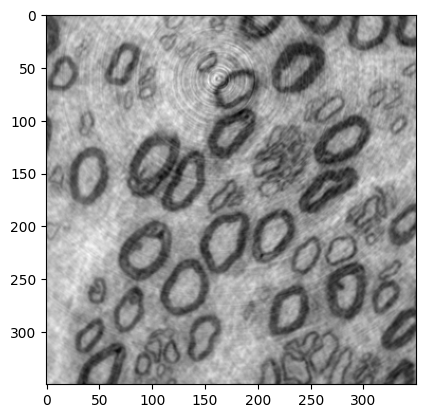

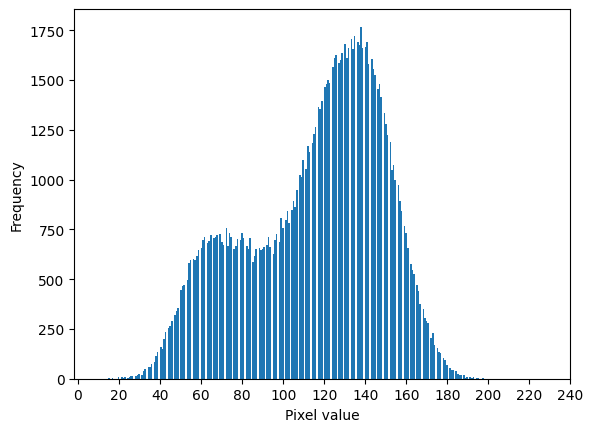

In [2]:
from tifffile import imread

img = imread("../data/nerves_part.tiff")
print(img.shape, img.dtype)


# Visualize slice of 3d image
import matplotlib.pyplot as plt
plt.imshow(img[0], cmap="gray")
plt.show()

# Visualize histogram of pixel values
plt.hist(img[0].flatten(), bins=256)
plt.xlabel("Pixel value")
plt.xticks(range(0, 256, 20))
plt.ylabel("Frequency")
plt.show()

## Segment first slice using MRF

In [46]:
import numpy as np
import maxflow
from scipy.ndimage import binary_opening, binary_closing

def segment_mrf(img_slice, beta=8, q=5):
    I = img_slice.astype(np.float32)
    I = (I - I.min()) / (I.max() - I.min())

    # Myelin = darkest pixels only
    t_dark = np.percentile(I, q)

    myelin_pixels = I[I < t_dark]
    bg_pixels = I[I > np.percentile(I, 60)]

    mu_myelin = np.mean(myelin_pixels)
    mu_bg = np.mean(bg_pixels)

    var_myelin = np.var(myelin_pixels) + 1e-6
    var_bg = np.var(bg_pixels) + 1e-6

    n, m = I.shape
    g = maxflow.Graph[float]()
    g.add_nodes(n * m)

    def idx(i, j):
        return i * m + j

    for i in range(n):
        for j in range(m):
            if i < n - 1:
                g.add_edge(idx(i, j), idx(i+1, j), beta, beta)
            if j < m - 1:
                g.add_edge(idx(i, j), idx(i, j+1), beta, beta)

    for i in range(n):
        for j in range(m):
            p = I[i, j]

            cost_myelin = (p - mu_myelin) ** 2 / var_myelin
            cost_bg = (p - mu_bg) ** 2 / var_bg

            g.add_tedge(idx(i, j), cost_bg, cost_myelin)

    g.maxflow()

    mask = np.zeros((n, m), dtype=bool)
    for i in range(n):
        for j in range(m):
            mask[i, j] = g.get_segment(idx(i, j)) == 0

    cleaned = binary_opening(mask, iterations=1)
    cleaned = binary_closing(cleaned, iterations=1)

    return mask, cleaned

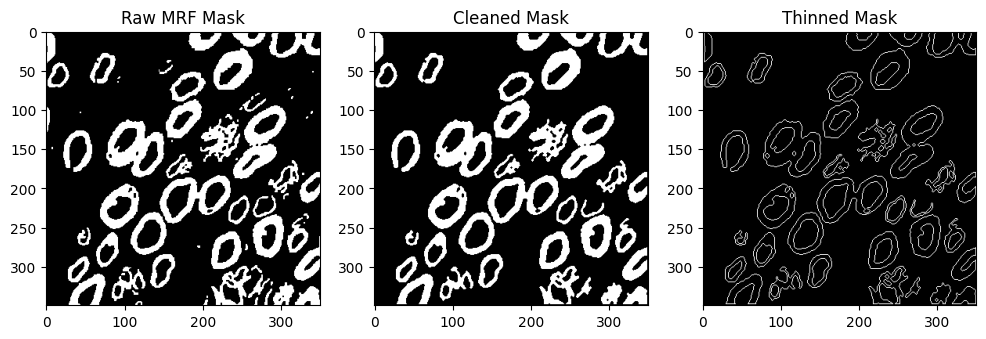

In [47]:
from skimage.morphology import remove_small_objects
from skimage.morphology import binary_erosion

mask, cleaned = segment_mrf(img[0], q=10)
cleaned = remove_small_objects(cleaned, min_size=150)
thin = cleaned ^ binary_erosion(cleaned)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(mask, cmap="gray")
plt.title("Raw MRF Mask")
plt.subplot(1, 3, 2)
plt.imshow(cleaned, cmap="gray")
plt.title("Cleaned Mask")
plt.subplot(1, 3, 3)
plt.imshow(thin, cmap="gray")
plt.title("Thinned Mask")
plt.show()

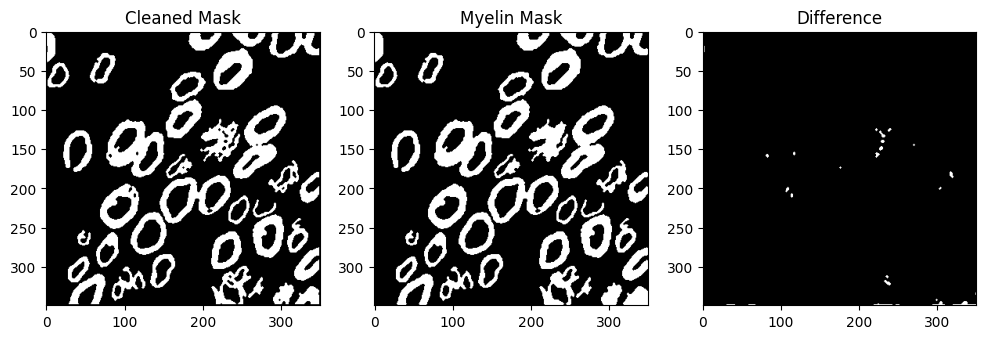

In [49]:
from skimage.morphology import remove_small_objects, remove_small_holes, binary_closing, disk
from skimage.measure import label, regionprops
from scipy.ndimage import binary_fill_holes
import numpy as np

myelin = cleaned.copy()

myelin = binary_closing(myelin, disk(1))
myelin = remove_small_objects(myelin, min_size=80)
myelin = remove_small_holes(myelin, area_threshold=40)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cleaned, cmap="gray")
plt.title("Cleaned Mask")
plt.subplot(1, 3, 2)
plt.imshow(myelin, cmap="gray")
plt.title("Myelin Mask")
plt.subplot(1, 3, 3)
plt.imshow(myelin ^ cleaned, cmap="gray")
plt.title("Difference")
plt.show()


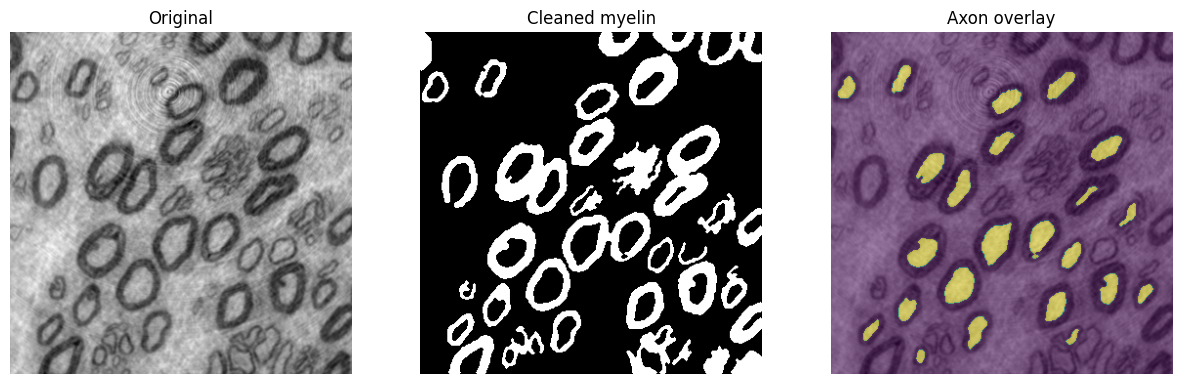

In [50]:
filled = binary_fill_holes(myelin)

labels = label(filled)
axon = np.zeros_like(filled, dtype=bool)

for r in regionprops(labels):
    area = r.area
    ecc = r.eccentricity
    solidity = r.solidity

    # tune these numbers
    if 100 < area < 5000 and ecc < 0.95 and solidity > 0.4:
        obj = labels == r.label
        candidate_axon = obj & ~myelin
        axon |= candidate_axon

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img[0], cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(myelin, cmap="gray")
plt.title("Cleaned myelin")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img[0], cmap="gray")
plt.imshow(axon, alpha=0.5)
plt.title("Axon overlay")
plt.axis("off")

plt.show()

### Watershed to seperate touching myelin

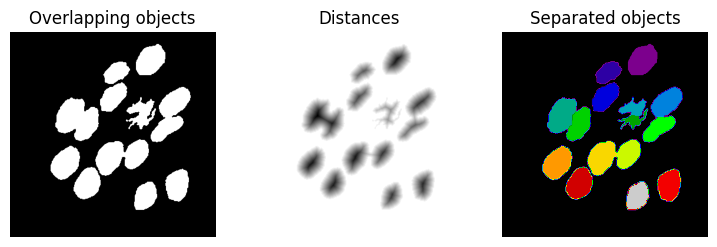

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import disk
from skimage.filters import gaussian


# Generate an initial image with two overlapping circles

image = cleaned

# 1. Distance Transform
distance = ndi.distance_transform_edt(image)

# 2. Smooth the distance map to avoid multiple peaks in one blob
# A small sigma (1.0 to 2.0) usually helps significantly
smoothed_distance = gaussian(distance, sigma=0.5)

# 3. Find peaks with a minimum distance between them
# Adjust min_distance based on the radius of your objects
coords = peak_local_max(smoothed_distance, min_distance=10, labels=image)

# 4. Create markers
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)

# 5. Watershed
# Using -smoothed_distance helps the "water" flow into the center of the blobs
labels = watershed(-smoothed_distance, markers, mask=image)
fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)

ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Overlapping objects')
ax[1].imshow(-distance, cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Separated objects')

for a in ax:
    a.set_axis_off()

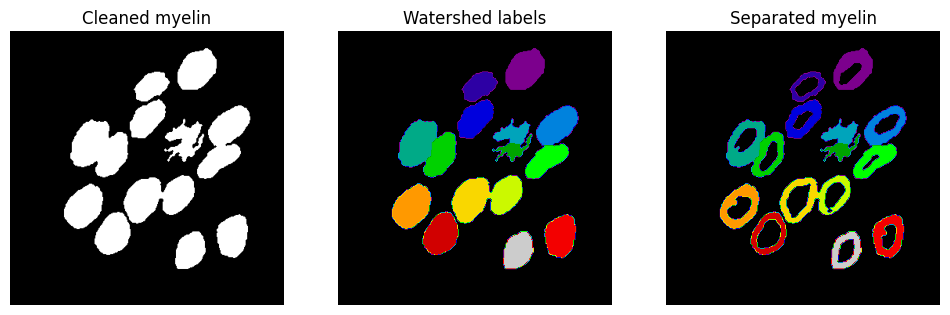

In [76]:
# Use watershed labels to separate myelin objects
separated_myelin_labels = labels.copy()
separated_myelin_labels[~myelin] = 0
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cleaned, cmap="gray")
plt.title("Cleaned myelin")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(labels, cmap="nipy_spectral")
plt.title("Watershed labels")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(separated_myelin_labels, cmap="nipy_spectral")
plt.title("Separated myelin")
plt.axis("off")

plt.show()

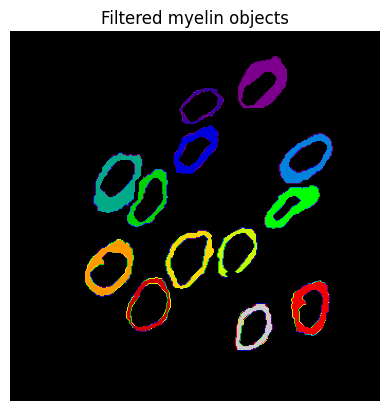

In [138]:
from skimage.measure import regionprops

labels = separated_myelin_labels.copy()

filtered = np.zeros_like(labels)

for r in regionprops(labels):    
    # bounding box mask
    minr, minc, maxr, maxc = r.bbox
    obj = labels[minr:maxr, minc:maxc] == r.label

    # check if object has a hole (axon inside)
    from scipy.ndimage import binary_fill_holes
    filled = binary_fill_holes(obj)
    
    has_hole = (filled.sum() - obj.sum()) > 20   # tune

    # filter criteria
    if (
        has_hole
    ):
        filtered[labels == r.label] = r.label
# Erode once OBS: filtered is not binary, but has labels, so we need to erode each label separately
eroded = np.zeros_like(filtered)
for r in regionprops(filtered):
    obj = filtered == r.label
    eroded_obj = binary_erosion(obj, disk(2))
    eroded[eroded_obj] = r.label


plt.imshow(eroded, cmap="nipy_spectral")
plt.title("Filtered myelin objects")
plt.axis("off")
plt.show()

## 3D segmentation using deformable model

### Select a nerve

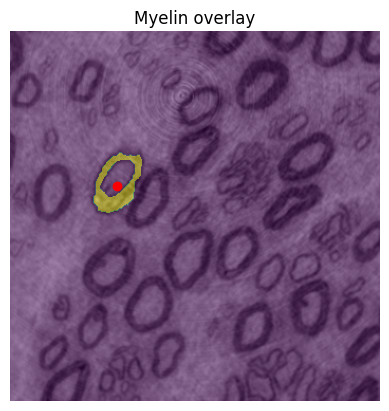

In [153]:
z = 0
im = img[z]

obj_id = 6
obj = eroded == obj_id

props = regionprops(eroded)
cy, cx = props[obj_id-2].centroid

plt.imshow(im, cmap="gray")
plt.imshow(obj, alpha=0.5)
plt.plot(cx, cy, "ro")  # plot centroid
plt.title("Myelin overlay")
plt.axis("off")
plt.show()


### Initialize snake from MRF segmentation

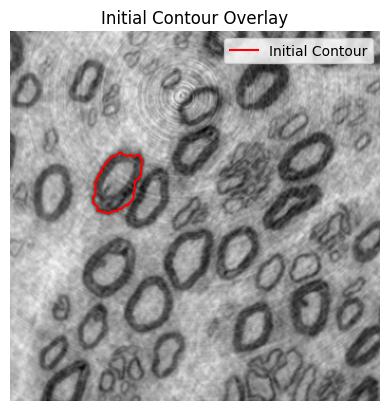

In [154]:
from skimage.measure import find_contours, label

contours = find_contours(obj.astype(float), 0.5)
init = max(contours, key=len)

# Visualize the initial contour
plt.imshow(im, cmap="gray")
plt.plot(init[:, 1], init[:, 0], 'r-', label='Initial Contour')
plt.title("Initial Contour Overlay")
plt.axis("off")
plt.legend()
plt.show()

In [160]:
obj_id = 6
obj = eroded == obj_id              # filled watershed object

# allow a small margin around the object
from skimage.morphology import binary_dilation, disk
roi = binary_dilation(obj, disk(1))

In [164]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

im_snake = im.copy()
im_snake[~roi] = np.median(im)   # neutral background, no strong nearby edges

snake = active_contour(
    gaussian(im_snake, sigma=2),
    init,
    alpha=0.02,
    beta=5.0,
    gamma=0.01,
    w_line=0,
    w_edge=1,
    max_num_iter=300
)

In [162]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

snake = active_contour(
    gaussian(im, sigma=2),
    init,
    alpha=0.02,
    beta=5.0,
    gamma=0.01,
    w_line=0,
    w_edge=1,
    max_num_iter=50
)

### Run snake through volume

In [167]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian
import numpy as np
import matplotlib.pyplot as plt

z0 = 0                  # slice where your current snake was made
snake0 = snake.copy()   # your good contour

snakes = {z0: snake0}

params = dict(
    alpha=0.02,
    beta=5.0,
    gamma=0.01,
    w_line=0,
    w_edge=1,
    max_num_iter=50,
    convergence=0.1
)

# forward propagation
prev = snake0.copy()
for z in range(z0 + 1, img.shape[0]):
    im_z = img[z]
    
    new_snake = active_contour(
        gaussian(im_z, sigma=2),
        prev,
        **params
    )
    
    snakes[z] = new_snake
    prev = new_snake

# backward propagation
prev = snake0.copy()
for z in range(z0 - 1, -1, -1):
    im_z = img[z]
    
    new_snake = active_contour(
        gaussian(im_z, sigma=2),
        prev,
        **params
    )
    
    snakes[z] = new_snake
    prev = new_snake

### Animate snake through volume

Animation size has reached 21018426 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


KeyboardInterrupt: 

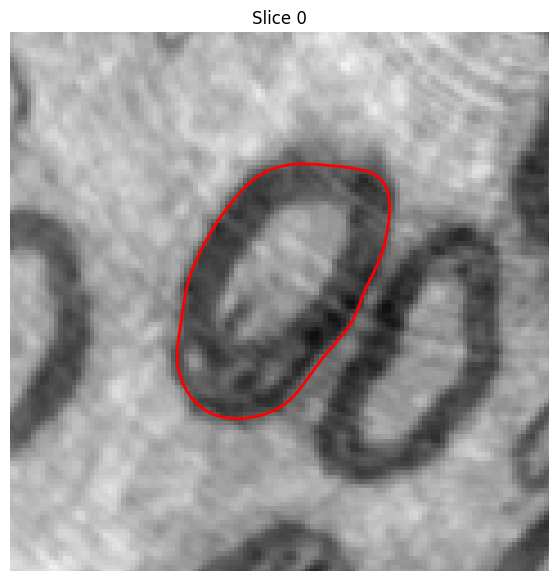

In [168]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

def update(z):
    ax.clear()
    ax.imshow(img[z], cmap="gray")
    
    s = snakes[z]
    ax.plot(s[:, 1], s[:, 0], "-r", linewidth=2)
    
    ax.set_title(f"Slice {z}")
    ax.axis("off")
    ax.set_xlim(cx - 60, cx + 60)
    ax.set_ylim(cy + 60, cy - 60)

ani = FuncAnimation(
    fig,
    update,
    frames=sorted(snakes.keys()),
    interval=80,
    repeat=True
)

HTML(ani.to_jshtml())


### Save as GIF

C:\Users\cvede\AppData\Local\Temp\ipykernel_40412\2778888821.py:15: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')


KeyboardInterrupt: 

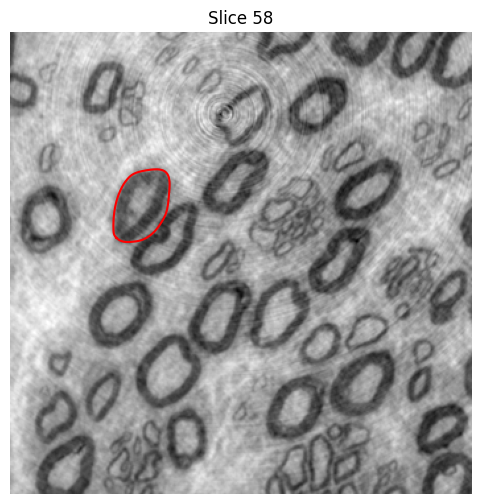

In [120]:
import imageio
frames = []

for z in sorted(snakes.keys())[:256]:  # limit to first 256 slices for smaller GIF
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(img[z], cmap="gray")
    
    s = snakes[z]
    ax.plot(s[:,1], s[:,0], "-r")
    
    ax.set_title(f"Slice {z}")
    ax.axis("off")
    
    fig.canvas.draw()
    frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    
    frames.append(frame)
    plt.close(fig)

imageio.mimsave("nerve_snake_part.gif", frames, fps=12)

## 3D visualization

In [169]:
def resample_contour(s, n_points=200):
    # cumulative distance
    d = np.sqrt(((np.diff(s, axis=0))**2).sum(axis=1))
    d = np.concatenate([[0], np.cumsum(d)])
    
    t = np.linspace(0, d[-1], n_points)
    
    new = np.zeros((n_points, 2))
    for i in range(2):
        new[:, i] = np.interp(t, d, s[:, i])
    
    return new

In [170]:
snakes_resampled = {
    z: resample_contour(s, 200)
    for z, s in snakes.items()
}

In [171]:
def align_start_point(s, ref):
    # find closest point in s to ref[0]
    dists = np.linalg.norm(s - ref[0], axis=1)
    idx = np.argmin(dists)
    
    return np.roll(s, -idx, axis=0)

In [172]:
aligned_snakes = {}
prev = snakes_resampled[z0]

aligned_snakes[z0] = prev

for z in range(z0 + 1, img.shape[0]):
    s = snakes_resampled[z]
    s = align_start_point(s, prev)
    aligned_snakes[z] = s
    prev = s

# backward
prev = snakes_resampled[z0]

for z in range(z0 - 1, -1, -1):
    s = snakes_resampled[z]
    s = align_start_point(s, prev)
    aligned_snakes[z] = s
    prev = s

In [173]:
from scipy.ndimage import gaussian_filter1d

for i in range(200):
    xs = np.array([aligned_snakes[z][i,1] for z in sorted(aligned_snakes)])
    ys = np.array([aligned_snakes[z][i,0] for z in sorted(aligned_snakes)])
    
    xs_smooth = gaussian_filter1d(xs, sigma=2)
    ys_smooth = gaussian_filter1d(ys, sigma=2)
    
    for j, z in enumerate(sorted(aligned_snakes)):
        aligned_snakes[z][i,1] = xs_smooth[j]
        aligned_snakes[z][i,0] = ys_smooth[j]

In [184]:
from skimage.draw import polygon
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

contours = aligned_snakes   # visualization contours

mask3d = np.zeros_like(img, dtype=bool)

for z, s in contours.items():
    rr, cc = polygon(s[:, 0], s[:, 1], img[z].shape)

    valid = (
        (rr >= 0) & (rr < img.shape[1]) &
        (cc >= 0) & (cc < img.shape[2])
    )

    mask3d[z, rr[valid], cc[valid]] = True

smooth_mask = gaussian_filter(mask3d.astype(float), sigma=1)

verts, faces, normals, values = marching_cubes(
    smooth_mask,
    level=0.5
)

In [185]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

z_scale = 3

# nerve surface
ax.plot_trisurf(
    verts[:, 2],
    verts[:, 1],
    verts[:, 0] * z_scale,
    triangles=faces,
    linewidth=0,
    alpha=0.95
)

# horizontal slice
z_slice = img.shape[0] // 2
slice_img = img[z_slice]
slice_norm = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min())

Y, X = np.mgrid[0:img.shape[1], 0:img.shape[2]]
Z = np.full_like(X, z_slice * z_scale)

ax.plot_surface(
    X, Y, Z,
    facecolors=plt.cm.gray(slice_norm),
    rstride=4,
    cstride=4,
    shade=False,
    alpha=0.45
)
ax.view_init(elev=25, azim=-45)
ax.set_box_aspect([1, 1, 3])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("slice")
ax.set_title("3D nerve surface with image slice")

plt.show()


<IPython.core.display.Javascript object>